# RevRadar — Customer Revenue & Churn Intelligence Platform
## Analyzing MRR Risk, Churn Patterns, and Retention Opportunities for a B2B SaaS Company

**Author:** Satvik  
**Dataset:** B2B SaaS CRM Export — 2023 (1,175 records)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---

### Project Objective
The VP of Revenue has flagged a growing churn problem heading into 2024.  
This notebook analyzes customer-level CRM data to:
- Identify churn patterns and revenue at risk
- Understand root causes by segment, plan, and quarter
- Flag at-risk active customers before they churn
- Deliver prioritized, data-backed retention recommendations

---
## Section 1 — Import Libraries
Importing all required Python libraries for data manipulation and visualization.

In [1]:
# ── Import Libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Libraries imported successfully")

Libraries imported successfully


---
## Section 2 — Load Dataset
Loading the raw CRM dataset and taking a first look at its structure,
shape, and column names.

In [2]:
# ── Load Raw Dataset ──────────────────────────────────────
df = pd.read_csv('../data/revradar_raw.csv')

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
print(list((df.columns)))

Dataset loaded successfully
Shape: 1175 rows × 15 columns

Column Names:
['Customer_ID', 'Quarter', 'Segment', 'Plan', 'Status', 'MRR_INR', 'Tenure_Months', 'Seats', 'Usage_Pct', 'CSAT', 'Industry', 'Churn_Reason', 'Onboarding_Type', 'Support_Tickets', 'Region']


---
## Section 3 — First Look at Data
Understanding the structure, data types, and initial preview of the dataset
before jumping into cleaning.

In [3]:
# Preview first 5 rows
print("First 5 rows:")
display(df.head())

# Dataset info - datatypes and non-null counts
print("\nDataset Info:")
df.info()

# Basic statistics for numerical columns
print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,Customer_ID,Quarter,Segment,Plan,Status,MRR_INR,Tenure_Months,Seats,Usage_Pct,CSAT,Industry,Churn_Reason,Onboarding_Type,Support_Tickets,Region
0,1,Q1,SMB,Starter,Active,3732,10,2,36,7.30,Logistics,NaN,Self-serve,5,East
1,2,Q1,Mid-Market,Growth,Active,18337,22,47,41,8.90,Media,NaN,Self-serve,3,West
2,3,Q1,SMB,Growth,Trial,17858,7,6,34,5.20,Ecommerce,Price,Assisted,4,East
3,4,Q1,Mid-Market,Growth,Churned,16357,26,9,40,4.30,Fintech,Missing features,Self-serve,12,South
4,5,Q1,Enterprise,Enterprise,Active,40788,11,179,46,7.00,Media,NaN,Enterprise CSM,3,North



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1175 non-null   int64  
 1   Quarter          1175 non-null   str    
 2   Segment          1175 non-null   str    
 3   Plan             1175 non-null   str    
 4   Status           1175 non-null   str    
 5   MRR_INR          1175 non-null   int64  
 6   Tenure_Months    1175 non-null   str    
 7   Seats            1175 non-null   int64  
 8   Usage_Pct        1175 non-null   int64  
 9   CSAT             1095 non-null   float64
 10  Industry         1175 non-null   str    
 11  Churn_Reason     296 non-null    str    
 12  Onboarding_Type  1137 non-null   str    
 13  Support_Tickets  1175 non-null   int64  
 14  Region           1118 non-null   str    
dtypes: float64(1), int64(5), str(9)
memory usage: 137.8 KB

Statistical Summary:


,Customer_ID,MRR_INR,Seats,Usage_Pct,CSAT,Support_Tickets
count,"1,175.00","1,175.00","1,175.00","1,175.00","1,095.00","1,175.00"
mean,570.23,"47,408.97",48.41,43.28,6.70,4.31
std,329.72,"448,142.33",53.96,18.42,1.51,3.49
min,1.00,-500.00,1.00,5.00,3.00,-5.00
25%,282.50,"4,436.50",8.00,30.00,5.70,2.00
50%,570.00,"14,975.00",29.00,43.00,6.90,4.00
75%,856.50,"43,644.50",68.00,58.00,7.90,6.00
max,"1,140.00","8,888,888.00",200.00,75.00,9.00,15.00


---
## Section 4 — Data Quality Check
Before cleaning, let's explicitly identify all data quality issues —
nulls, duplicates, wrong data types, outliers, and logical errors.

In [4]:
# 1. Check null values
print("NULL VALUES:")
print(df.isnull().sum())

# 2. Check duplicates
print(f"\nDUPLICATE ROWS: {df.duplicated().sum()}")

# 3. Check data types
print(f"\nDATA TYPES:")
print(df.dtypes)

# 4. Check unique values in categorical columns
print(f"\nUNIQUE VALUES — Segment:")
print(df['Segment'].unique())

print(f"\nUNIQUE VALUES — Plan:")
print(df['Plan'].unique())

# 5. Check MRR outliers
print(f"\nMRR OUTLIERS:")
print(df[df['MRR_INR'] < 0]['MRR_INR'].value_counts())
print(df[df['MRR_INR'] > 500000]['MRR_INR'].value_counts())

# 6. Check negative support tickets
print(f"\nNEGATIVE SUPPORT TICKETS:")
print(df[df['Support_Tickets'] < 0]['Support_Tickets'].value_counts())

NULL VALUES:
Customer_ID          0
Quarter              0
Segment              0
Plan                 0
Status               0
MRR_INR              0
Tenure_Months        0
Seats                0
Usage_Pct            0
CSAT                80
Industry             0
Churn_Reason       879
Onboarding_Type     38
Support_Tickets      0
Region              57
dtype: int64

DUPLICATE ROWS: 33

DATA TYPES:
Customer_ID          int64
Quarter                str
Segment                str
Plan                   str
Status                 str
MRR_INR              int64
Tenure_Months          str
Seats                int64
Usage_Pct            int64
CSAT               float64
Industry               str
Churn_Reason           str
Onboarding_Type        str
Support_Tickets      int64
Region                 str
dtype: object

UNIQUE VALUES — Segment:
<StringArray>
[       'SMB', 'Mid-Market', 'Enterprise', 'Mid market', 'mid-market',
        'smb', 'ENTERPRISE', 'enterprise', 'MID-MARKET',        'S

---
## Section 5 — Data Cleaning
Fixing all identified data quality issues one by one.
Each step is documented with before/after validation.

In [5]:
# Working copy
df_clean = df.copy()

print(f"Starting shape: {df_clean.shape}")

# ── Step 1: Remove Duplicates ──────────────────────────────
df_clean = df_clean.drop_duplicates()
print(f"\nStep 1 — Duplicates removed")
print(f"Shape after removing duplicates: {df_clean.shape}")

# ── Step 2: Fix Casing — Segment ──────────────────────────
df_clean['Segment'] = df_clean['Segment'].str.strip().str.title()
df_clean['Segment'] = df_clean['Segment'].replace({
    'Mid Market': 'Mid-Market',
    'Smb': 'SMB'
})

print(f"\nStep 2 — Segment casing fixed")
print(df_clean['Segment'].unique())

# ── Step 3: Fix Casing — Plan ─────────────────────────────
df_clean['Plan'] = df_clean['Plan'].str.strip().str.title()
print(f"\nStep 3 — Plan casing fixed")
print(df_clean['Plan'].unique())

# ── Step 4: Fix Tenure_Months dtype ───────────────────────
df_clean['Tenure_Months'] = df_clean['Tenure_Months'].astype(str)
df_clean['Tenure_Months'] = df_clean['Tenure_Months'].str.extract(r'(\d+)').astype(int)
print(f"\nStep 4 — Tenure_Months dtype fixed")
print(df_clean['Tenure_Months'].dtype)

# ── Step 5: Fix MRR Outliers ──────────────────────────────
median_mrr = df_clean[
    (df_clean['MRR_INR'] > 0) & 
    (df_clean['MRR_INR'] < 500000)
]['MRR_INR'].median()

df_clean.loc[df_clean['MRR_INR'] <= 0, 'MRR_INR'] = median_mrr
df_clean.loc[df_clean['MRR_INR'] > 500000, 'MRR_INR'] = median_mrr
print(f"\nStep 5 — MRR outliers fixed (replaced with median: ₹{median_mrr:,.0f})")

# ── Step 6: Fix Negative Support Tickets ──────────────────
df_clean['Support_Tickets'] = df_clean['Support_Tickets'].clip(lower=0)
print(f"\nStep 6 — Negative Support Tickets fixed")
print(f"Min Support Tickets now: {df_clean['Support_Tickets'].min()}")

# ── Step 7: Fix Null — CSAT ───────────────────────────────
csat_median = df_clean['CSAT'].median()
df_clean['CSAT'] = df_clean['CSAT'].fillna(csat_median)
print(f"\nStep 7 — CSAT nulls filled with median: {csat_median}")

# ── Step 8: Fix Null — Region ─────────────────────────────
region_mode = df_clean['Region'].mode()[0]
df_clean['Region'] = df_clean['Region'].fillna(region_mode)
print(f"\nStep 8 — Region nulls filled with mode: {region_mode}")

# ── Step 9: Fix Null — Onboarding_Type ───────────────────
df_clean['Onboarding_Type'] = df_clean['Onboarding_Type'].fillna('Unknown')
print(f"\nStep 9 — Onboarding_Type nulls filled with 'Unknown'")

# ── Step 10: Fix Churn_Reason — Logical Error ─────────────
df_clean.loc[
    df_clean['Status'].isin(['Active', 'Trial']) & 
    df_clean['Churn_Reason'].notna(),
    'Churn_Reason'
] = None

df_clean['Churn_Reason'] = df_clean['Churn_Reason'].fillna('Not Applicable')
print(f"\nStep 10 — Churn_Reason logical errors fixed")

# ── Step 11: Strip Whitespace — Industry ──────────────────
df_clean['Industry'] = df_clean['Industry'].str.strip()
print(f"\nStep 11 — Industry whitespace stripped")

# ── Step 12: Final duplicate check after casing fixes ─────
df_clean = df_clean.drop_duplicates()
print(f"\nStep 12 — Final duplicate removal after casing fixes")
print(f"Final shape: {df_clean.shape}")

# ── Final Shape ───────────────────────────────────────────
print(f"\n{'='*50}")
print(f"CLEANING COMPLETE")
print(f"Original shape : {df.shape}")
print(f"Cleaned shape  : {df_clean.shape}")
print(f"Rows removed   : {df.shape[0] - df_clean.shape[0]}")

Starting shape: (1175, 15)

Step 1 — Duplicates removed
Shape after removing duplicates: (1142, 15)

Step 2 — Segment casing fixed
<StringArray>
['SMB', 'Mid-Market', 'Enterprise']
Length: 3, dtype: str

Step 3 — Plan casing fixed
<StringArray>
['Starter', 'Growth', 'Enterprise']
Length: 3, dtype: str

Step 4 — Tenure_Months dtype fixed
int64

Step 5 — MRR outliers fixed (replaced with median: ₹15,075)

Step 6 — Negative Support Tickets fixed
Min Support Tickets now: 0

Step 7 — CSAT nulls filled with median: 6.9

Step 8 — Region nulls filled with mode: East

Step 9 — Onboarding_Type nulls filled with 'Unknown'

Step 10 — Churn_Reason logical errors fixed

Step 11 — Industry whitespace stripped

Step 12 — Final duplicate removal after casing fixes
Final shape: (1140, 15)

CLEANING COMPLETE
Original shape : (1175, 15)
Cleaned shape  : (1140, 15)
Rows removed   : 35


---
## Section 6 — Cleaning Validation
Verifying that all data quality issues have been resolved.

In [6]:
# ── Cleaning Validation ───────────────────────────────────

print("NULL VALUES AFTER CLEANING:")
print(df_clean.isnull().sum())

print(f"\nDUPLICATES AFTER CLEANING: {df_clean.duplicated().sum()}")

print(f"\nMRR RANGE:")
print(f"Min: ₹{df_clean['MRR_INR'].min():,.0f}")
print(f"Max: ₹{df_clean['MRR_INR'].max():,.0f}")

print(f"\nSUPPORT TICKETS MIN: {df_clean['Support_Tickets'].min()}")

print(f"\nTENURE DTYPE: {df_clean['Tenure_Months'].dtype}")

print(f"\nSEGMENT UNIQUE: {df_clean['Segment'].unique()}")
print(f"\nPLAN UNIQUE: {df_clean['Plan'].unique()}")

print(f"\n{'='*50}")
print(f"ALL CHECKS PASSED — Data is clean and ready for analysis")

NULL VALUES AFTER CLEANING:
Customer_ID        0
Quarter            0
Segment            0
Plan               0
Status             0
MRR_INR            0
Tenure_Months      0
Seats              0
Usage_Pct          0
CSAT               0
Industry           0
Churn_Reason       0
Onboarding_Type    0
Support_Tickets    0
Region             0
dtype: int64

DUPLICATES AFTER CLEANING: 0

MRR RANGE:
Min: ₹2,012
Max: ₹79,865

SUPPORT TICKETS MIN: 0

TENURE DTYPE: int64

SEGMENT UNIQUE: <StringArray>
['SMB', 'Mid-Market', 'Enterprise']
Length: 3, dtype: str

PLAN UNIQUE: <StringArray>
['Starter', 'Growth', 'Enterprise']
Length: 3, dtype: str

ALL CHECKS PASSED — Data is clean and ready for analysis


---
## Section 7 — Save Clean Dataset
Saving the cleaned dataframe as a new CSV file for further analysis.

In [7]:
# ── Save Cleaned Dataset ──────────────────────────────────
df_clean.to_csv('../data/revradar_clean.csv', index=False)

print(f"Clean dataset saved → data/revradar_clean.csv")
print(f"Final shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

Clean dataset saved → data/revradar_clean.csv
Final shape: 1140 rows × 15 columns


---
## Section 8 — Exploratory Data Analysis (EDA)
Analyzing cleaned data to uncover churn patterns, revenue distribution,
and business insights across segments, plans, and quarters.

In [15]:
# Chart styling setup
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

colors = {
    'primary'  : '#2563EB',
    'danger'   : '#DC2626',
    'warning'  : '#D97706',
    'success'  : '#16A34A',
    'neutral'  : '#6B7280'
}

print("Chart styling configured")

Chart styling configured


In [8]:
# Churn distribution — how many customers per status
status_counts = df_clean['Status'].value_counts()
status_pct = df_clean['Status'].value_counts(normalize=True) * 100

print("Customer Status Distribution:")
print("-" * 35)
for status in status_counts.index:
    print(f"{status:<12} {status_counts[status]:>5} customers  ({status_pct[status]:.1f}%)")

print("-" * 35)
print(f"{'Total':<12} {status_counts.sum():>5} customers")

Customer Status Distribution:
-----------------------------------
Active         652 customers  (57.2%)
Churned        249 customers  (21.8%)
Trial          131 customers  (11.5%)
Paused         108 customers  (9.5%)
-----------------------------------
Total         1140 customers


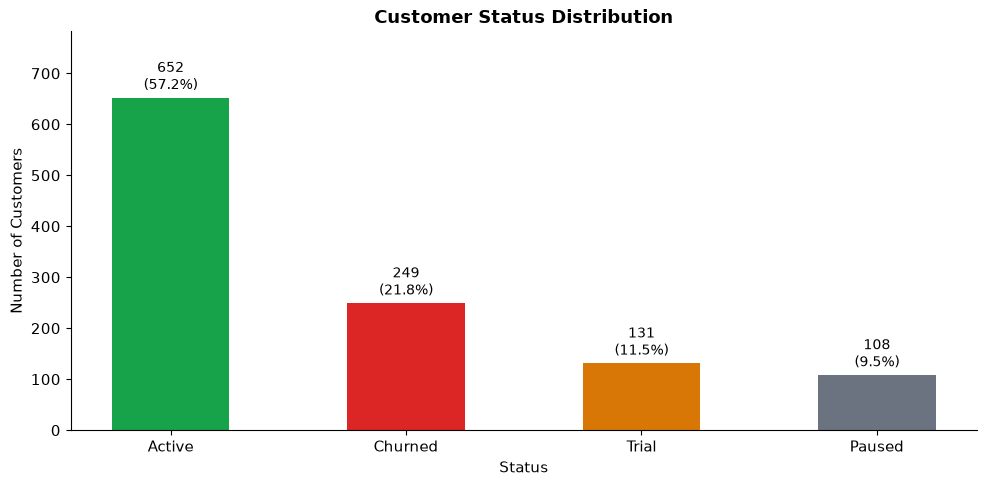

In [20]:
# Chart 1 — Customer Status Distribution
fig, ax = plt.subplots()

statuses = status_counts.index.tolist()
counts = status_counts.values.tolist()
bar_colors = [colors['success'], colors['danger'], colors['warning'], colors['neutral']]

bars = ax.bar(statuses, counts, color=bar_colors, width=0.5)

for bar, count, pct in zip(bars, counts, status_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Customer Status Distribution')
ax.set_xlabel('Status')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, max(counts) * 1.2)

plt.tight_layout()
plt.savefig('../assets/chart1_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
### EDA 1 — Customer Status Distribution
652 active customers (57.2%) generating recurring revenue.
249 churned customers (21.8%) indicate a significant retention problem.
131 trial customers represent upsell opportunity if converted.

In [9]:
# Churn rate by quarter — is it getting worse over time?
quarter_total = df_clean.groupby('Quarter')['Customer_ID'].count()
quarter_churned = df_clean[df_clean['Status'] == 'Churned'].groupby('Quarter')['Customer_ID'].count()
churn_rate = (quarter_churned / quarter_total * 100).round(1)

print("Churn Rate by Quarter:")
print("-" * 35)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    total = quarter_total[q]
    churned = quarter_churned[q]
    rate = churn_rate[q]
    print(f"{q}    Total: {total:>4}   Churned: {churned:>4}   Rate: {rate:>5}%")
print("-" * 35)

Churn Rate by Quarter:
-----------------------------------
Q1    Total:  240   Churned:   42   Rate:  17.5%
Q2    Total:  270   Churned:   51   Rate:  18.9%
Q3    Total:  300   Churned:   80   Rate:  26.7%
Q4    Total:  330   Churned:   76   Rate:  23.0%
-----------------------------------


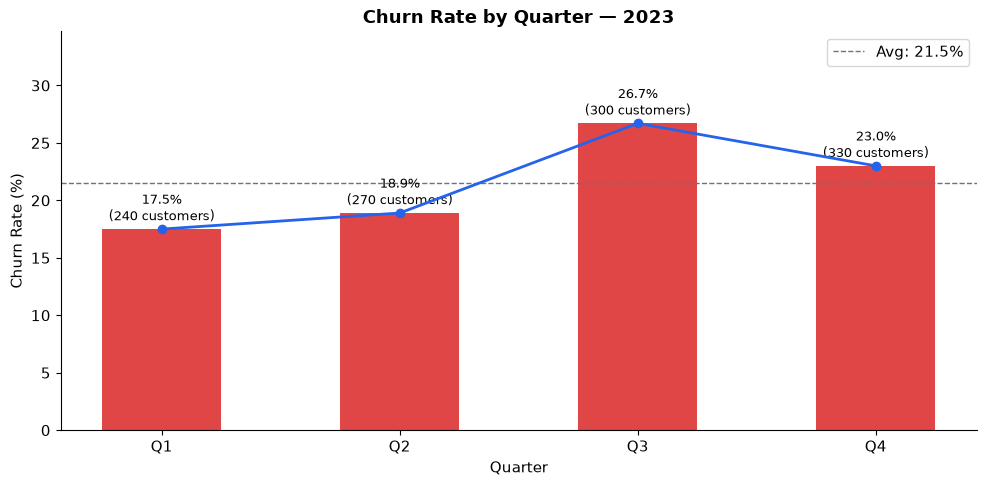

In [19]:
# Chart 2 — Churn Rate by Quarter
fig, ax = plt.subplots()

quarters = ['Q1', 'Q2', 'Q3', 'Q4']
rates = [churn_rate[q] for q in quarters]
total_customers = [quarter_total[q] for q in quarters]

bars = ax.bar(quarters, rates, color=colors['danger'], width=0.5, alpha=0.85)

ax.plot(quarters, rates, color=colors['primary'], marker='o',
        linewidth=2, markersize=6, zorder=5)

for bar, rate, total in zip(bars, rates, total_customers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{rate}%\n({total} customers)', ha='center', va='bottom', fontsize=9)

ax.set_title('Churn Rate by Quarter — 2023')
ax.set_xlabel('Quarter')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, max(rates) * 1.3)
ax.axhline(y=sum(rates)/len(rates), color=colors['neutral'],
           linestyle='--', linewidth=1, label=f'Avg: {sum(rates)/len(rates):.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('../assets/chart2_churn_rate_by_quarter.png', dpi=150, bbox_inches='tight')
plt.show()

---
### EDA 2 — Churn Rate by Quarter
Churn rate increased sharply from 17.5% in Q1 to 26.7% in Q3 — a 67% jump.
H1 churned 93 customers vs H2 churned 156 customers.
Q3 spike indicates a structural trigger — price change, competitor activity, or product gap.

In [10]:
# MRR analysis by segment — where is revenue concentrated?
segment_mrr = df_clean[df_clean['Status'] == 'Active'].groupby('Segment')['MRR_INR'].sum()
segment_customers = df_clean[df_clean['Status'] == 'Active'].groupby('Segment')['Customer_ID'].count()
segment_avg_mrr = df_clean[df_clean['Status'] == 'Active'].groupby('Segment')['MRR_INR'].mean()
total_mrr = segment_mrr.sum()

print("Active MRR by Segment:")
print("-" * 65)
print(f"{'Segment':<15} {'Customers':>10} {'Total MRR':>15} {'% of MRR':>10} {'Avg MRR':>12}")
print("-" * 65)
for seg in ['SMB', 'Mid-Market', 'Enterprise']:
    customers = segment_customers[seg]
    mrr = segment_mrr[seg]
    pct = (mrr / total_mrr * 100)
    avg = segment_avg_mrr[seg]
    print(f"{seg:<15} {customers:>10} {mrr:>15,.0f} {pct:>9.1f}% {avg:>12,.0f}")
print("-" * 65)
print(f"{'Total':<15} {segment_customers.sum():>10} {total_mrr:>15,.0f} {'100.0%':>10}")

Active MRR by Segment:
-----------------------------------------------------------------
Segment          Customers       Total MRR   % of MRR      Avg MRR
-----------------------------------------------------------------
SMB                    210       1,885,296      11.4%        8,978
Mid-Market             212       4,919,303      29.7%       23,204
Enterprise             230       9,775,584      59.0%       42,503
-----------------------------------------------------------------
Total                  652      16,580,183     100.0%


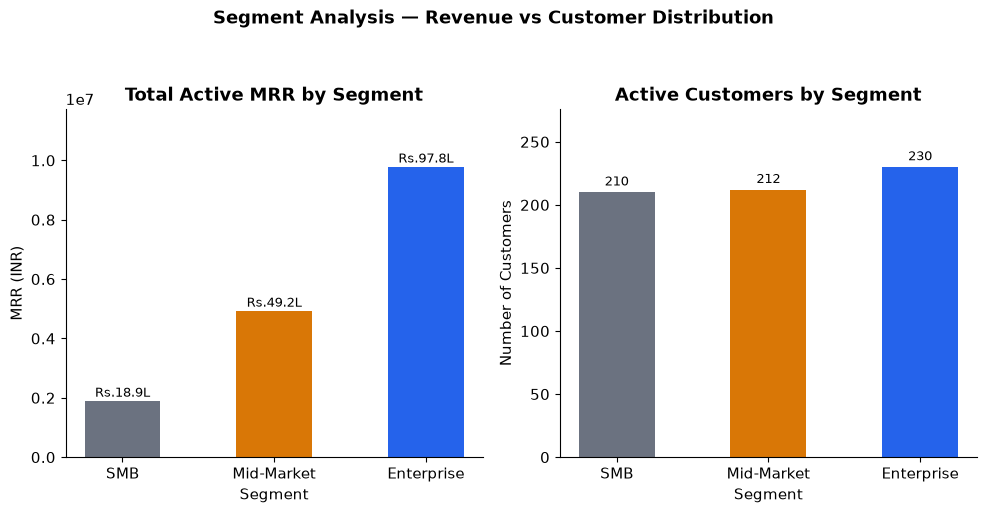

In [21]:
# Chart 3 — Active MRR by Segment
fig, axes = plt.subplots(1, 2)

segments = ['SMB', 'Mid-Market', 'Enterprise']
mrr_values = [segment_mrr[s] for s in segments]
customer_counts = [segment_customers[s] for s in segments]
seg_colors = [colors['neutral'], colors['warning'], colors['primary']]

# Left chart — Total MRR by Segment
bars = axes[0].bar(segments, mrr_values, color=seg_colors, width=0.5)
for bar, mrr in zip(bars, mrr_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
                 f'Rs.{mrr/100000:.1f}L', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Total Active MRR by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('MRR (INR)')
axes[0].set_ylim(0, max(mrr_values) * 1.2)

# Right chart — Customer Count by Segment
bars2 = axes[1].bar(segments, customer_counts, color=seg_colors, width=0.5)
for bar, count in zip(bars2, customer_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{count}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Active Customers by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, max(customer_counts) * 1.2)

plt.suptitle('Segment Analysis — Revenue vs Customer Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/chart3_mrr_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

---
### EDA 3 — Active MRR by Segment
Enterprise segment contributes 59% of total active MRR (Rs. 97.7L) from only 35% of customers.
Average Enterprise MRR is 4.7x higher than SMB — indicating severe concentration risk.
Losing 3 Enterprise accounts = losing ~14 SMB accounts in revenue terms.

In [11]:
# Churn reason analysis — why are customers leaving and what is the revenue impact?
churned_df = df_clean[df_clean['Status'] == 'Churned'].copy()

churn_reason_count = churned_df.groupby('Churn_Reason')['Customer_ID'].count()
churn_reason_mrr = churned_df.groupby('Churn_Reason')['MRR_INR'].sum()
churn_reason_avg = churned_df.groupby('Churn_Reason')['MRR_INR'].mean()

total_churned_mrr = churn_reason_mrr.sum()

print("Churn Reason Analysis — Revenue Impact:")
print("-" * 75)
print(f"{'Churn Reason':<20} {'Customers':>10} {'Lost MRR':>15} {'% of Loss':>10} {'Avg MRR':>12}")
print("-" * 75)

for reason in churn_reason_mrr.sort_values(ascending=False).index:
    count = churn_reason_count[reason]
    mrr = churn_reason_mrr[reason]
    pct = (mrr / total_churned_mrr * 100)
    avg = churn_reason_avg[reason]
    print(f"{reason:<20} {count:>10} {mrr:>15,.0f} {pct:>9.1f}% {avg:>12,.0f}")

print("-" * 75)
print(f"{'Total':<20} {churn_reason_count.sum():>10} {total_churned_mrr:>15,.0f} {'100.0%':>10}")

Churn Reason Analysis — Revenue Impact:
---------------------------------------------------------------------------
Churn Reason          Customers        Lost MRR  % of Loss      Avg MRR
---------------------------------------------------------------------------
Missing features             61       1,637,901      26.7%       26,851
Competitor                   43       1,576,906      25.7%       36,672
Price                        61       1,096,440      17.9%       17,974
Poor UX                      34         688,019      11.2%       20,236
Budget cut                   23         613,050      10.0%       26,654
No response                  23         507,692       8.3%       22,074
Not Applicable                4          15,669       0.3%        3,917
---------------------------------------------------------------------------
Total                       249       6,135,677     100.0%


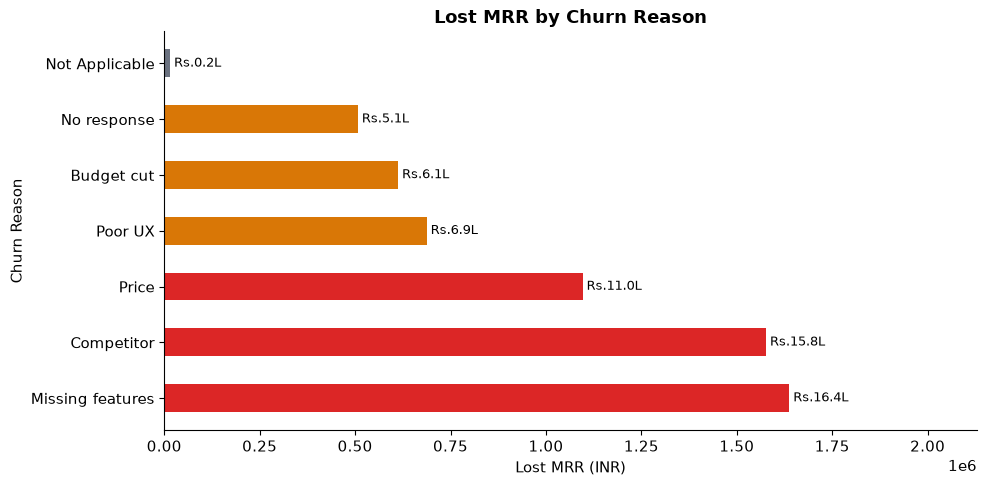

In [22]:
# Chart 4 — Lost MRR by Churn Reason
fig, ax = plt.subplots()

reasons = churn_reason_mrr.sort_values(ascending=False).index.tolist()
mrr_lost = churn_reason_mrr.sort_values(ascending=False).values.tolist()

reason_colors = [colors['danger'] if m > 1000000 else 
                 colors['warning'] if m > 500000 else 
                 colors['neutral'] for m in mrr_lost]

bars = ax.barh(reasons, mrr_lost, color=reason_colors, height=0.5)

for bar, mrr in zip(bars, mrr_lost):
    ax.text(bar.get_width() + 10000,
            bar.get_y() + bar.get_height()/2,
            f'Rs.{mrr/100000:.1f}L',
            ha='left', va='center', fontsize=9)

ax.set_title('Lost MRR by Churn Reason')
ax.set_xlabel('Lost MRR (INR)')
ax.set_ylabel('Churn Reason')
ax.set_xlim(0, max(mrr_lost) * 1.3)

plt.tight_layout()
plt.savefig('../assets/chart4_churn_reason_mrr.png', dpi=150, bbox_inches='tight')
plt.show()

---
### EDA 4 — Churn Reason Analysis
Missing Features (Rs. 16.4L) and Competitor (Rs. 15.8L) together account for 52.4% of total lost MRR.
Competitor churners have the highest avg MRR at Rs. 36,672 — most valuable customers leaving.
Price-driven churn is high in volume (61 customers) but lower in revenue impact (avg MRR Rs. 17,974).

In [12]:
# CSAT analysis — leading indicator of churn risk
csat_by_status = df_clean.groupby('Status')['CSAT'].mean().round(2)
usage_by_status = df_clean.groupby('Status')['Usage_Pct'].mean().round(1)

print("CSAT and Usage by Status:")
print("-" * 50)
print(f"{'Status':<12} {'Avg CSAT':>10} {'Avg Usage %':>12}")
print("-" * 50)
for status in ['Active', 'Churned', 'Trial', 'Paused']:
    csat = csat_by_status[status]
    usage = usage_by_status[status]
    print(f"{status:<12} {csat:>10.2f} {usage:>11.1f}%")
print("-" * 50)

# At-risk active customers — low CSAT and low usage
at_risk = df_clean[
    (df_clean['Status'] == 'Active') &
    (df_clean['CSAT'] < 7.0) &
    (df_clean['Usage_Pct'] < 45)
].copy()

print(f"\nAt-Risk Active Customers (CSAT < 7.0 and Usage < 45%):")
print("-" * 50)
print(f"Total at-risk accounts    : {len(at_risk)}")
print(f"Total MRR at risk         : Rs. {at_risk['MRR_INR'].sum():,.0f}")
print(f"Avg CSAT (at-risk)        : {at_risk['CSAT'].mean():.2f}")
print(f"Avg Usage % (at-risk)     : {at_risk['Usage_Pct'].mean():.1f}%")

CSAT and Usage by Status:
--------------------------------------------------
Status         Avg CSAT  Avg Usage %
--------------------------------------------------
Active             7.54        55.2%
Churned            4.68        20.6%
Trial              6.57        34.4%
Paused             6.56        35.5%
--------------------------------------------------

At-Risk Active Customers (CSAT < 7.0 and Usage < 45%):
--------------------------------------------------
Total at-risk accounts    : 53
Total MRR at risk         : Rs. 1,079,399
Avg CSAT (at-risk)        : 6.59
Avg Usage % (at-risk)     : 39.8%


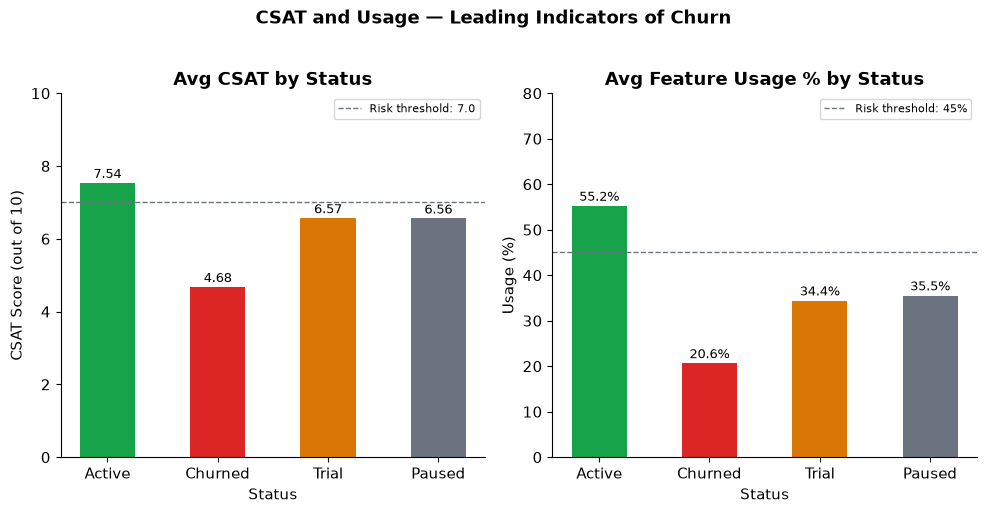

In [23]:
# Chart 5 — CSAT and Usage by Status
fig, axes = plt.subplots(1, 2)

statuses = ['Active', 'Churned', 'Trial', 'Paused']
csat_values = [csat_by_status[s] for s in statuses]
usage_values = [usage_by_status[s] for s in statuses]
status_colors = [colors['success'], colors['danger'], colors['warning'], colors['neutral']]

# Left chart — Avg CSAT by Status
bars1 = axes[0].bar(statuses, csat_values, color=status_colors, width=0.5)
for bar, val in zip(bars1, csat_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Avg CSAT by Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('CSAT Score (out of 10)')
axes[0].set_ylim(0, 10)
axes[0].axhline(y=7.0, color=colors['neutral'], linestyle='--',
                linewidth=1, label='Risk threshold: 7.0')
axes[0].legend(fontsize=8)

# Right chart — Avg Usage % by Status
bars2 = axes[1].bar(statuses, usage_values, color=status_colors, width=0.5)
for bar, val in zip(bars2, usage_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Avg Feature Usage % by Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Usage (%)')
axes[1].set_ylim(0, 80)
axes[1].axhline(y=45, color=colors['neutral'], linestyle='--',
                linewidth=1, label='Risk threshold: 45%')
axes[1].legend(fontsize=8)

plt.suptitle('CSAT and Usage — Leading Indicators of Churn', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/chart5_csat_usage_by_status.png', dpi=150, bbox_inches='tight')
plt.show()

---
### EDA 5 — CSAT and Usage as Leading Indicators
Churned customers averaged CSAT 4.68 vs Active 7.54 — a 2.86 point gap.
53 active customers currently show CSAT below 7.0 and Usage below 45% — pre-churn signals.
Rs. 10.8L MRR at risk from these accounts — immediate CSM intervention recommended.

In [13]:
# Churn analysis by plan — which plan has highest churn problem?
plan_total = df_clean.groupby('Plan')['Customer_ID'].count()
plan_churned = df_clean[df_clean['Status'] == 'Churned'].groupby('Plan')['Customer_ID'].count()
plan_churned_mrr = df_clean[df_clean['Status'] == 'Churned'].groupby('Plan')['MRR_INR'].sum()
plan_churn_rate = (plan_churned / plan_total * 100).round(1)

print("Churn Analysis by Plan:")
print("-" * 70)
print(f"{'Plan':<12} {'Total':>8} {'Churned':>9} {'Churn Rate':>11} {'Lost MRR':>14}")
print("-" * 70)
for plan in ['Starter', 'Growth', 'Enterprise']:
    total = plan_total[plan]
    churned = plan_churned[plan]
    rate = plan_churn_rate[plan]
    lost_mrr = plan_churned_mrr[plan]
    print(f"{plan:<12} {total:>8} {churned:>9} {rate:>10.1f}% {lost_mrr:>14,.0f}")
print("-" * 70)
print(f"{'Total':<12} {plan_total.sum():>8} {plan_churned.sum():>9} {'':>11} {plan_churned_mrr.sum():>14,.0f}")

Churn Analysis by Plan:
----------------------------------------------------------------------
Plan            Total   Churned  Churn Rate       Lost MRR
----------------------------------------------------------------------
Starter           344        71       20.6%        250,269
Growth            405        94       23.2%      1,302,478
Enterprise        391        84       21.5%      4,582,930
----------------------------------------------------------------------
Total            1140       249                  6,135,677


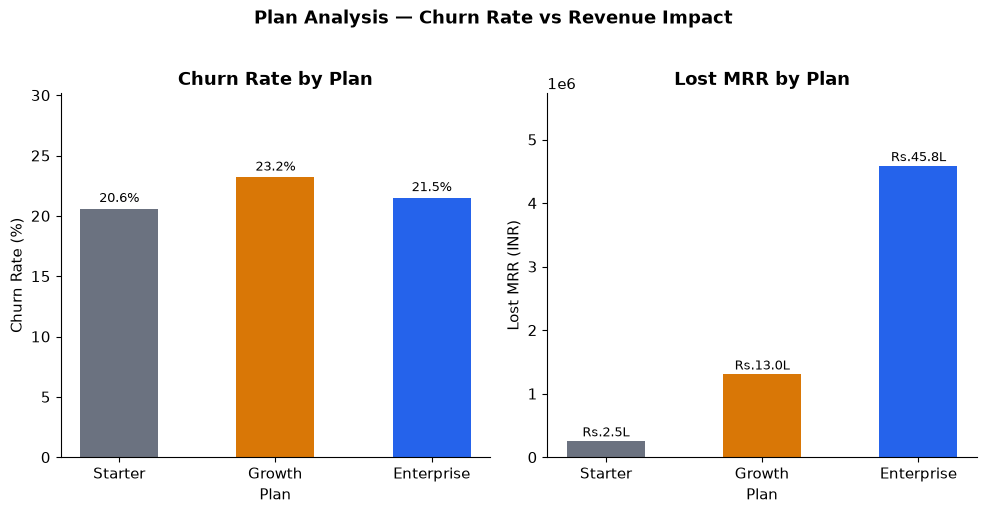

In [24]:
# Chart 6 — Churn Rate and Lost MRR by Plan
fig, axes = plt.subplots(1, 2)

plans = ['Starter', 'Growth', 'Enterprise']
churn_rates = [plan_churn_rate[p] for p in plans]
lost_mrr = [plan_churned_mrr[p] for p in plans]
plan_colors = [colors['neutral'], colors['warning'], colors['primary']]

# Left chart — Churn Rate by Plan
bars1 = axes[0].bar(plans, churn_rates, color=plan_colors, width=0.5)
for bar, rate in zip(bars1, churn_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate}%', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Churn Rate by Plan')
axes[0].set_xlabel('Plan')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, max(churn_rates) * 1.3)

# Right chart — Lost MRR by Plan
bars2 = axes[1].bar(plans, lost_mrr, color=plan_colors, width=0.5)
for bar, mrr in zip(bars2, lost_mrr):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
                 f'Rs.{mrr/100000:.1f}L', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Lost MRR by Plan')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Lost MRR (INR)')
axes[1].set_ylim(0, max(lost_mrr) * 1.25)

plt.suptitle('Plan Analysis — Churn Rate vs Revenue Impact', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/chart6_churn_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()

---
### EDA 6 — Churn Analysis by Plan
Enterprise plan accounts for 74.7% of total lost MRR (Rs. 45.8L) despite mid-level churn rate (21.5%).
Growth plan has the highest churn rate at 23.2% — mid-market customers at highest attrition risk.
Starter churn is high in volume but low in revenue impact — pricing strategy review needed.

In [14]:
# Revenue and churn summary — final business snapshot
print("=" * 60)
print("REVRADAR — BUSINESS HEALTH SUMMARY")
print("=" * 60)

print(f"\nCUSTOMER BASE:")
print(f"  Total customers          : {len(df_clean):,}")
print(f"  Active customers         : {(df_clean['Status'] == 'Active').sum():,}")
print(f"  Churned customers        : {(df_clean['Status'] == 'Churned').sum():,}")
print(f"  Overall churn rate       : {(df_clean['Status'] == 'Churned').sum() / len(df_clean) * 100:.1f}%")

print(f"\nREVENUE:")
active_df = df_clean[df_clean['Status'] == 'Active']
churned_df = df_clean[df_clean['Status'] == 'Churned']
print(f"  Total active MRR         : Rs. {active_df['MRR_INR'].sum():,.0f}")
print(f"  Total lost MRR (churned) : Rs. {churned_df['MRR_INR'].sum():,.0f}")
print(f"  Enterprise MRR share     : {active_df[active_df['Segment'] == 'Enterprise']['MRR_INR'].sum() / active_df['MRR_INR'].sum() * 100:.1f}%")

print(f"\nCHURN INSIGHTS:")
print(f"  H1 churned customers     : {df_clean[df_clean['Quarter'].isin(['Q1','Q2']) & (df_clean['Status'] == 'Churned')].shape[0]}")
print(f"  H2 churned customers     : {df_clean[df_clean['Quarter'].isin(['Q3','Q4']) & (df_clean['Status'] == 'Churned')].shape[0]}")
print(f"  Top churn reason         : Missing features (Rs. 16.4L lost)")
print(f"  Highest avg MRR lost     : Competitor (Rs. 36,672 avg)")

print(f"\nAT-RISK SIGNALS:")
print(f"  At-risk active accounts  : {len(at_risk)}")
print(f"  MRR at risk              : Rs. {at_risk['MRR_INR'].sum():,.0f}")
print(f"  Active avg CSAT          : {active_df['CSAT'].mean():.2f}")
print(f"  Churned avg CSAT         : {churned_df['CSAT'].mean():.2f}")

print(f"\nTOP RECOMMENDATIONS:")
print(f"  1. CSM outreach to 53 at-risk accounts — protect Rs. 10.8L MRR")
print(f"  2. Product roadmap — fix top missing features — Rs. 16.4L at stake")
print(f"  3. Competitive analysis — why Enterprise leaving to competitor")
print(f"  4. Growth plan retention — highest churn rate at 23.2%")
print(f"  5. Starter pricing review — 61 customers lost on price")
print("=" * 60)

REVRADAR — BUSINESS HEALTH SUMMARY

CUSTOMER BASE:
  Total customers          : 1,140
  Active customers         : 652
  Churned customers        : 249
  Overall churn rate       : 21.8%

REVENUE:
  Total active MRR         : Rs. 16,580,183
  Total lost MRR (churned) : Rs. 6,135,677
  Enterprise MRR share     : 59.0%

CHURN INSIGHTS:
  H1 churned customers     : 93
  H2 churned customers     : 156
  Top churn reason         : Missing features (Rs. 16.4L lost)
  Highest avg MRR lost     : Competitor (Rs. 36,672 avg)

AT-RISK SIGNALS:
  At-risk active accounts  : 53
  MRR at risk              : Rs. 1,079,399
  Active avg CSAT          : 7.54
  Churned avg CSAT         : 4.68

TOP RECOMMENDATIONS:
  1. CSM outreach to 53 at-risk accounts — protect Rs. 10.8L MRR
  2. Product roadmap — fix top missing features — Rs. 16.4L at stake
  3. Competitive analysis — why Enterprise leaving to competitor
  4. Growth plan retention — highest churn rate at 23.2%
  5. Starter pricing review — 61 custome